In [19]:
import zipfile

zip_path = "/content/swis_2026Mar15T070619336.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/swis_data")

print("Files extracted successfully!")

Files extracted successfully!


# Introduction

The solar wind is a continuous stream of charged particles emitted from the Sun that fills interplanetary space. Variations in solar wind particle flux can provide important insights into solar activity and the dynamic plasma environment in the heliosphere. Studying these variations helps scientists understand space weather processes and the interaction between solar wind and planetary magnetospheres.

In this project, solar wind particle flux data obtained from Aditya-L1 are analyzed. The measurements were recorded by the ASPEX, which detects solar wind particles and measures their flux across different energy channels.

The dataset used in this analysis consists of particle flux observations for 1 March and 2 March 2026, provided in Common Data Format (CDF) files. These data are processed using Google Colab to extract the relevant variables and visualize the particle flux as a function of time.

The main objective of this analysis is to examine how solar wind particle flux varies during the selected observation period and to identify any noticeable spikes, trends, or fluctuations in different energy channels. By studying these variations, we aim to gain insight into the temporal behavior of solar wind particles and the changing plasma conditions in interplanetary space.

In [3]:
import os
os.listdir("/content/swis_data")

['AL1_ASW91_L2_TH2_20260228_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L1_TH1_20260228_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L1_TH1_20260302_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L1_TH2_20260302_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L2_TH1_20260228_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L2_TH1_20260302_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L1_AUX_20260302_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L2_BLK_20260228_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L2_BLK_20260302_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L1_TH2_20260228_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L1_AUX_20260301_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L2_BLK_20260301_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L1_AUX_20260228_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L2_TH2_20260301_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L1_TH1_20260301_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L1_TH2_20260301_UNP_9999_999999_V01.cdf',
 'AL1_ASW91_L2_TH1_20260301_UNP_9999_999999_V02.cdf',
 'AL1_ASW91_L2_TH2_20260302_UNP_9999_999999_V02.cdf']

In [7]:
!pip install cdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 3.0 MB/s eta 0:00:00


In [8]:
import cdflib

In [9]:
cdf = cdflib.CDF('/content/swis_data/AL1_ASW91_L2_TH1_20260301_UNP_9999_999999_V02.cdf')
print(cdf.cdf_info())

CDFInfo(CDF=PosixPath('/tmp/tmp_1mt_q_o.cdf'), Version='3.9.0', Encoding=6, Majority='Column_major', rVariables=[], zVariables=['epoch_for_cdf_mod', 'energy_center_mod', 'energy_uncer', 'integrated_flux_mod', 'flux_uncer', 'integrated_flux_s9_mod', 'integrated_flux_s10_mod', 'integrated_flux_s11_mod', 'spacecraft_xpos', 'spacecraft_ypos', 'spacecraft_zpos', 'sun_angle_tha1'], Attributes=[{'TITLE': 'Global'}, {'FIELDNAME': 'Variable'}, {'UNITS': 'Variable'}, {'CATDESC': 'Variable'}, {'DEPEND_0': 'Variable'}, {'DEPEND_1': 'Variable'}, {'DEPEND_2': 'Variable'}, {'DISPLAY_TYPE': 'Variable'}, {'FILLVAL': 'Variable'}, {'FORMAT': 'Variable'}, {'LABLAXIS': 'Variable'}, {'LABL_PTR_1': 'Variable'}, {'VALIDMIN': 'Variable'}, {'VALIDMAX': 'Variable'}, {'VAR_TYPE': 'Variable'}, {'SCALETYP': 'Variable'}, {'VAR_NOTES': 'Variable'}, {'AVG_TYPE': 'Variable'}, {'DELTA_PLUS_VAR': 'Variable'}, {'DELTA_MINUS_VAR': 'Variable'}, {'DICT_KEY': 'Variable'}, {'MONOTON': 'Variable'}, {'SCALEMIN': 'Variable'}, {'S

In [10]:
time = cdf.varget('epoch_for_cdf_mod')
flux = cdf.varget('integrated_flux_mod')

In [11]:
from cdflib import cdfepoch

time_readable = cdfepoch.to_datetime(time)

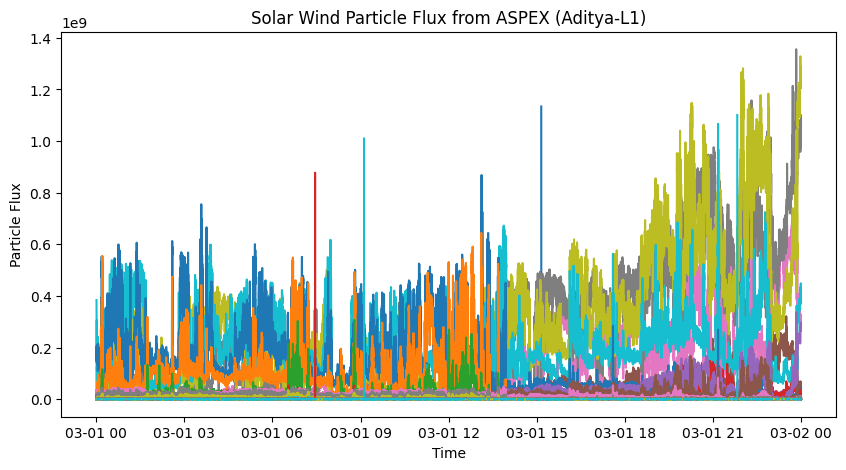

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(time_readable, flux)

plt.xlabel("Time")
plt.ylabel("Particle Flux")
plt.title("Solar Wind Particle Flux from ASPEX (Aditya-L1)")

plt.show()

# **Particle Flux Analysis for 1 March 2026**

The variation of particle flux with time on 1 March 2026 was examined using data obtained from ASPEX onboard Aditya-L1. The plotted graph shows particle flux for different energy channels represented by different colored curves.

# Observation and Interpretation

In the initial time interval from 00:00 to approximately 06:00, the blue, orange, and green curves remain relatively close to each other. The blue curve shows slightly higher values compared to the orange and green curves, while the red curve appears significantly lower during this period. This indicates that during the early hours of the day, particle flux across most energy channels remains stable, suggesting relatively quiet solar wind conditions.

Around 06:00, a noticeable spike appears in the red curve, representing the higher energy particle channel. This spike is short-lived and does not appear strongly in the other energy channels. Such a sudden enhancement suggests a brief increase in high-energy particle flux, which may indicate a localized energetic particle event.

Moving toward 09:00, the blue curve shows a clear spike, indicating an increase in particle flux within that energy range. This suggests a temporary increase in solar wind particle activity detected by the instrument.

Later in the day, beginning around 15:00, the green curve begins to rise gradually and eventually surpasses the blue and orange curves. This increase continues until approximately 21:00, indicating a sustained enhancement of particles within this intermediate energy range. The gradual rise suggests evolving solar wind conditions during the later part of the observation period.

Additionally, the pink curve, representing measurement uncertainty, remains relatively small during the early hours of the day. However, it increases gradually toward the later part of the day. This increase in uncertainty likely reflects higher variability in particle flux as solar wind activity becomes more dynamic.

Overall, the observations indicate that while the early hours of 1 March 2026 were characterized by relatively stable solar wind conditions, several spikes and gradual increases in particle flux later in the day suggest enhanced particle activity in the solar wind environment.

In [14]:
cdf = cdflib.CDF('/content/swis_data/AL1_ASW91_L2_TH1_20260302_UNP_9999_999999_V02.cdf')
print(cdf.cdf_info())

CDFInfo(CDF=PosixPath('/tmp/tmpqy50x83s.cdf'), Version='3.9.0', Encoding=6, Majority='Column_major', rVariables=[], zVariables=['epoch_for_cdf_mod', 'energy_center_mod', 'energy_uncer', 'integrated_flux_mod', 'flux_uncer', 'integrated_flux_s9_mod', 'integrated_flux_s10_mod', 'integrated_flux_s11_mod', 'spacecraft_xpos', 'spacecraft_ypos', 'spacecraft_zpos', 'sun_angle_tha1'], Attributes=[{'TITLE': 'Global'}, {'FIELDNAME': 'Variable'}, {'UNITS': 'Variable'}, {'CATDESC': 'Variable'}, {'DEPEND_0': 'Variable'}, {'DEPEND_1': 'Variable'}, {'DEPEND_2': 'Variable'}, {'DISPLAY_TYPE': 'Variable'}, {'FILLVAL': 'Variable'}, {'FORMAT': 'Variable'}, {'LABLAXIS': 'Variable'}, {'LABL_PTR_1': 'Variable'}, {'VALIDMIN': 'Variable'}, {'VALIDMAX': 'Variable'}, {'VAR_TYPE': 'Variable'}, {'SCALETYP': 'Variable'}, {'VAR_NOTES': 'Variable'}, {'AVG_TYPE': 'Variable'}, {'DELTA_PLUS_VAR': 'Variable'}, {'DELTA_MINUS_VAR': 'Variable'}, {'DICT_KEY': 'Variable'}, {'MONOTON': 'Variable'}, {'SCALEMIN': 'Variable'}, {'S

In [15]:
time = cdf.varget('epoch_for_cdf_mod')
flux = cdf.varget('integrated_flux_mod')

In [16]:
from cdflib import cdfepoch

time_readable = cdfepoch.to_datetime(time)

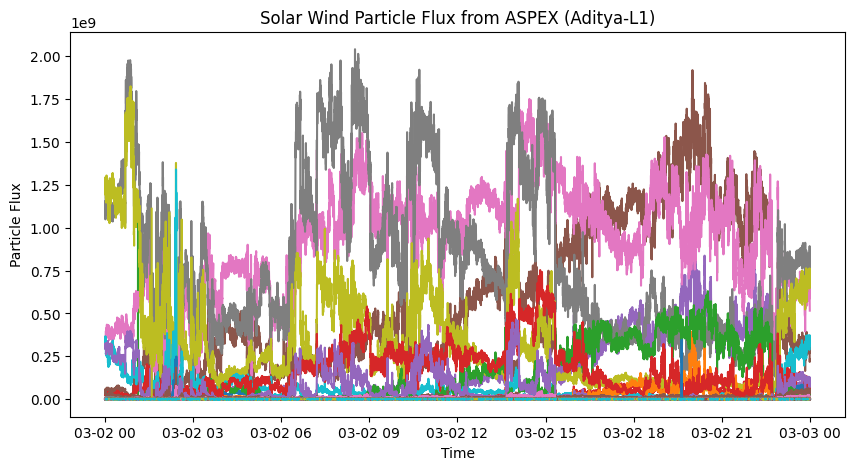

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(time_readable, flux)

plt.xlabel("Time")
plt.ylabel("Particle Flux")
plt.title("Solar Wind Particle Flux from ASPEX (Aditya-L1)")

plt.show()

# Observation and Interpretation – 2 March 2026

The particle flux variation observed on 2 March 2026 shows significant fluctuations across multiple energy channels throughout the day. At the beginning of the observation period, the green channel displays relatively high particle flux compared to other channels. However, between approximately 03:00 and 06:00 hours, a noticeable decrease in the green flux intensity occurs, indicating a temporary reduction in particle activity within that energy range.

After this period of decline, the particle flux gradually stabilizes and remains relatively moderate for several hours. Later in the day, an interesting pattern appears in the dark green channel. While this channel shows very low intensity during the early part of the observation period, it begins to increase noticeably after approximately 18:00 hours and continues rising toward 00:00 hours. This behavior suggests that higher-energy particle activity becomes more prominent during the later hours of the day.

Several other channels exhibit patterns that generally follow the variation observed in the green channel, indicating correlated behavior among different particle energy levels. The red channel shows activity across most of the observation period, suggesting the presence of a continuous background particle flux.

In contrast, the blue channel shows very limited activity during the entire observation window. Only one noticeable spike appears between approximately 02:00 and 03:00 hours, indicating a short-lived burst of particle flux at that energy level.

Among all observed channels, the gray channel displays the highest particle flux values throughout the day. This is followed by the pink channel and then the green channel. The red channel shows moderate flux intensity, while the dark green channel remains relatively weaker for most of the observation period, except for the increase observed during the late hours of the day.

Overall, the particle flux distribution for 2 March 2026 indicates dynamic solar wind conditions, with variations occurring across different energy channels at different times. The fluctuations and spikes observed in the data suggest changing particle populations in the solar wind environment during the observation period.



# Comparative Discussion

Comparing the two days, the particle flux on 1 March shows relatively stable behavior during the early hours followed by gradual increases later in the day, particularly in the intermediate energy channel. In contrast, the observations on 2 March display more irregular fluctuations with several energy channels varying throughout the day.

The differences in flux patterns between the two days highlight the dynamic nature of the solar wind environment near the Sun–Earth L1 region. Variations in particle flux across different energy channels indicate changes in particle populations and energy distributions within the solar wind.

Overall, the analysis demonstrates that solar wind particle flux can vary significantly over short time scales, reflecting the continuously evolving plasma conditions in interplanetary space.

# Conclusion

In this study, solar wind particle flux data from Aditya-L1 were analyzed using measurements from the ASPEX instrument. The particle flux variations for 1 March and 2 March 2026 were examined by plotting flux values for different energy channels as a function of time.

The analysis revealed that particle flux exhibits noticeable fluctuations throughout the day, with several spikes and gradual increases observed across different energy channels. These variations indicate that solar wind particle populations are not constant but evolve continuously over time. Differences in the intensity of the colored curves suggest that particles with different energy levels respond differently to changes in solar wind conditions.

The particle flux values observed in this dataset ranged approximately between 0 and
2
×
10
9
2×10
9
, indicating moderate solar wind activity during the observation period. Some short-lived spikes suggest transient increases in particle intensity, while gradual increases later in the day indicate evolving plasma conditions in the interplanetary medium.

Overall, the results demonstrate the dynamic nature of the solar wind environment and highlight the importance of continuous monitoring of particle flux in space. Such observations contribute to a better understanding of solar wind behavior and space weather processes near the Sun–Earth L1 region.